Modèle de propension (régression logistique), évaluation aléatoire stratifiée et temporelle

In [14]:
# connexion

import os
from getpass import getpass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

password = os.environ.get("BANK_DB_PASSWORD") or getpass("Mot de passe analyst : ")
engine = create_engine(URL.create(
    "postgresql+psycopg2", username="analyst", password=password,
    host="localhost", port=5432, database="bank"))
os.makedirs("../docs/figures", exist_ok=True)

In [15]:
# préparation des variables

df = pd.read_sql("SELECT * FROM bank_clean ORDER BY row_id", engine)

CAT = ["job", "marital", "education", "credit_default", "housing", "loan", "poutcome"]
NUM = ["age", "balance", "previous", "days_since_last_contact", "previously_contacted"]

X = df[CAT + NUM].copy()
X[CAT] = X[CAT].fillna("inconnu")                       # unknown / jamais contacté = catégorie
X["days_since_last_contact"] = X["days_since_last_contact"].fillna(0)  # le drapeau previously_contacted porte l'information
X["balance"] = np.sign(X["balance"]) * np.log1p(X["balance"].abs())    # limite l'effet des valeurs extrêmes
X["previous"] = X["previous"].clip(upper=10)             # valeur extrême (max 275) plafonnée
y = df["converted"]
print(X.shape, round(y.mean(), 4))

(45211, 12) 0.117


In [16]:
# modèle et métriques

def build_model():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("num", StandardScaler(), NUM),
    ])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])


def lift_metrics(y_true, score, fractions=(0.1, 0.2)):
    d = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(score)}).sort_values("s", ascending=False)
    base = d["y"].mean()
    out = {}
    for f in fractions:
        top = d.head(int(len(d) * f))
        out[f"lift_top{int(f * 100)}%"] = top["y"].mean() / base
        out[f"capture_top{int(f * 100)}%"] = top["y"].sum() / d["y"].sum()
    return out


def evaluate(name, X_tr, y_tr, X_te, y_te):
    model = build_model().fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    res = {"evaluation": name, "n_test": len(y_te),
           "taux_reel_test": y_te.mean(), "proba_moyenne_predite": p.mean(),
           "ROC_AUC": roc_auc_score(y_te, p),
           "PR_AUC": average_precision_score(y_te, p),
           **lift_metrics(y_te, p)}
    return model, p, res

In [17]:
# les deux évaluations

# A. Découpage aléatoire stratifié 70/30
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
model_a, p_a, res_a = evaluate("A. aléatoire stratifié", Xa_tr, ya_tr, Xa_te, ya_te)

# B. Découpage temporel : 70 % premières lignes (row_id <= 31 648) / 30 % dernières
tr = df["row_id"] <= 31648
model_b, p_b, res_b = evaluate("B. temporel", X[tr], y[tr], X[~tr], y[~tr])

results = pd.DataFrame([res_a, res_b]).set_index("evaluation").round(3).T
results

evaluation,A. aléatoire stratifié,B. temporel
n_test,13564.000,13563.000
taux_reel_test,0.117,0.254
proba_moyenne_predite,0.117,0.071
ROC_AUC,0.726,0.723
PR_AUC,0.361,0.493
lift_top10%,3.429,2.514
capture_top10%,0.343,0.251
lift_top20%,2.458,2.079
capture_top20%,0.491,0.416


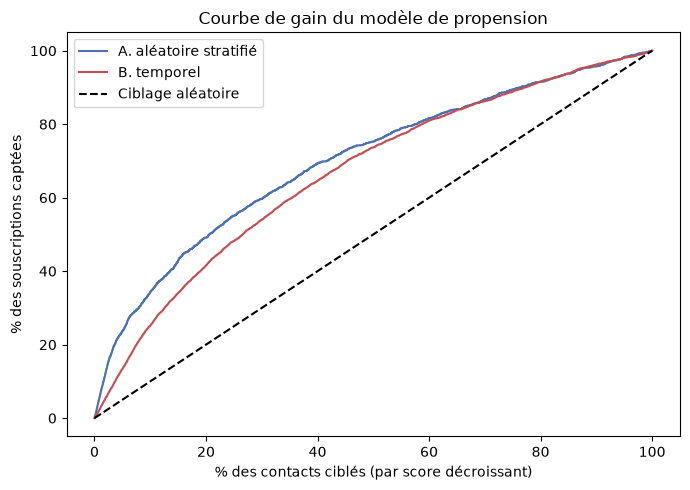

In [18]:
# courbes de gain

def gain_curve(y_true, score):
    d = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(score)}).sort_values("s", ascending=False)
    x = np.arange(1, len(d) + 1) / len(d)
    return x, (d["y"].cumsum() / d["y"].sum()).values

fig, ax = plt.subplots(figsize=(7, 5))
for label, yt, p, color in [("A. aléatoire stratifié", ya_te, p_a, "#4C72B0"),
                            ("B. temporel", y[~tr], p_b, "#C44E52")]:
    gx, gy = gain_curve(yt, p)
    ax.plot(100 * gx, 100 * gy, label=label, color=color)
ax.plot([0, 100], [0, 100], "k--", label="Ciblage aléatoire")
ax.set_xlabel("% des contacts ciblés (par score décroissant)")
ax.set_ylabel("% des souscriptions captées")
ax.set_title("Courbe de gain du modèle de propension")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/courbe_de_gain.png", dpi=150)
plt.show()

In [19]:
# coefficients (interprétation)

names = model_a.named_steps["pre"].get_feature_names_out()
coefs = pd.DataFrame({"variable": names,
                      "coef": model_a.named_steps["clf"].coef_[0]})
coefs["odds_ratio"] = np.exp(coefs["coef"])
coefs.reindex(coefs["coef"].abs().sort_values(ascending=False).index).head(10).round(3)


,variable,coef,odds_ratio
28,cat__poutcome_success,1.369,3.930
25,cat__poutcome_failure,-0.819,0.441
27,cat__poutcome_other,-0.615,0.541
22,cat__housing_yes,-0.613,0.542
6,cat__job_retired,0.532,1.702
9,cat__job_student,0.512,1.668
26,cat__poutcome_inconnu,-0.499,0.607
24,cat__loan_yes,-0.460,0.631
3,cat__job_housemaid,-0.416,0.659
13,cat__marital_married,-0.392,0.675


In [20]:
names = model_a.named_steps["pre"].get_feature_names_out()
comp = pd.DataFrame({"variable": names,
                     "coef_A": model_a.named_steps["clf"].coef_[0],
                     "coef_B": model_b.named_steps["clf"].coef_[0]})
comp["meme_signe"] = np.sign(comp["coef_A"]) == np.sign(comp["coef_B"])
print(f"Part des coefficients de même signe en A et en B : {comp['meme_signe'].mean():.0%}")
print(comp.loc[comp["variable"].str.startswith("num__")].round(3))   # âge, solde, historique
comp.sort_values("coef_A", key=abs, ascending=False).head(12).round(3)

Part des coefficients de même signe en A et en B : 85%
                        variable  coef_A  coef_B  meme_signe
29                      num__age   0.000  -0.077       False
30                  num__balance   0.243   0.198        True
31                 num__previous   0.071  -0.030       False
32  num__days_since_last_contact   0.048  -0.106       False
33     num__previously_contacted   0.180   0.020        True


,variable,coef_A,coef_B,meme_signe
28,cat__poutcome_success,1.369,0.858,True
25,cat__poutcome_failure,-0.819,-0.602,True
27,cat__poutcome_other,-0.615,-0.293,True
22,cat__housing_yes,-0.613,-0.470,True
6,cat__job_retired,0.532,0.387,True
9,cat__job_student,0.512,0.290,True
26,cat__poutcome_inconnu,-0.499,-0.603,True
24,cat__loan_yes,-0.460,-0.424,True
3,cat__job_housemaid,-0.416,-0.539,True
13,cat__marital_married,-0.392,-0.472,True


In [21]:
comp[~comp["meme_signe"]].assign(ecart=lambda d: (d["coef_A"] - d["coef_B"]).abs()).sort_values("ecart", ascending=False).round(3)

,variable,coef_A,coef_B,meme_signe,ecart
21,cat__housing_no,0.049,-0.170,False,0.219
32,num__days_since_last_contact,0.048,-0.106,False,0.154
31,num__previous,0.071,-0.030,False,0.101
29,num__age,0.000,-0.077,False,0.077
0,cat__job_admin.,0.021,-0.030,False,0.051
